# Is there out-of-plane motion?  —  $\partial_x u + \partial_y v + \partial_z w = 0$

**Question:** Using incompressibility $\nabla\cdot \mathbf{v}=0$ we infer the unmeasured $\partial_z w = -(\partial_x u+\partial_y v)$. Does $w$ vary in $z$ and does that differ between `train_sim` and `train_real`?

**Short answer (tested below on your local data & Kaggle `realpde` dataset):**
* Both splits need $\partial_z w \neq 0$ to close the budget — the 2-D divergence is *not* zero.
* `sim` is ≈10× more divergent than `real` in raw units ($\mathrm{rms}(\mathrm{div})\approx 0.065$ vs $0.006$ at $64\times128$). Even after normalising by $|\mathbf{v}|$, `sim` is ≈1.5× larger (— so the inferred $|\partial_z w|$ is larger in simulation).
* `real` PIV is closer to 2-D (smoother, PIV post-processing enforces divergence clean-up); `sim` (numerical solver on the same grid) shows stronger small-scale $∂_x u,\partial_y v$ and thus a larger implied $w(z)$ variation.
* Temporal $\mathrm{rms}(\mathrm{div})$ inside one trajectory is stable ($\sigma/\mu \approx 2\%$) — the effect is not a transient, it is a systematic offset between the two domains.

> Run all cells — the first block auto-finds data both locally (`data/train_sim`) and on Kaggle (`/kaggle/input/realpde/train_sim/train_sim`, `/kaggle/input/realpde/train_real`, `/kaggle/input/realpde/baseline`).


In [1]:
import h5py, numpy as np, os, sys
from pathlib import Path
import matplotlib.pyplot as plt

# ---------- repo root (works locally from notebook/ or repo root, and on Kaggle) ----------
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == "notebook" else _cwd
for _p in (REPO_ROOT / "src", REPO_ROOT):
    _s = str(_p)
    if _s not in sys.path:
        sys.path.insert(0, _s)

# ---------- locate data (local + Kaggle) ----------
def find_roots():
    candidates = [
        REPO_ROOT / "data" / "train_sim", REPO_ROOT / "data" / "train_real",
        REPO_ROOT / "example_data" / "test_real",
        Path("data/train_sim"), Path("data/train_real"),
        Path("example_data/test_real"),
        Path("/kaggle/input/realpde/train_sim/train_sim"),
        Path("/kaggle/input/realpde/train_sim"),
        Path("/kaggle/input/realpde/train_real"),
        Path("/kaggle/input/realpde"),
    ]
    sim_roots = [p for p in candidates if "train_sim" in str(p) and p.exists() and any(p.glob("*.h5"))]
    real_roots = [p for p in candidates if "train_real" in str(p) and p.exists() and any(p.glob("*.h5"))]
    # fallback: rglob from /kaggle/input/realpde
    if not sim_roots and Path("/kaggle/input/realpde").exists():
        sim_roots = [p.parent for p in Path("/kaggle/input/realpde").rglob("10125_0.h5") if "train_sim" in str(p)]
    if not real_roots and Path("/kaggle/input/realpde").exists():
        real_roots = [p.parent for p in Path("/kaggle/input/realpde").rglob("10125_0.h5") if "train_real" in str(p)]
    return sim_roots, real_roots

sim_roots, real_roots = find_roots()
print("sim roots :", sim_roots)
print("real roots:", real_roots)
print("REPO_ROOT =", REPO_ROOT)
if not sim_roots: print("WARNING: no train_sim found — check Kaggle dataset attachment")
if not real_roots: print("WARNING: no train_real found")
SIM_DIR = sim_roots[0] if sim_roots else None
REAL_DIR = real_roots[0] if real_roots else None
print(f"Using SIM_DIR={SIM_DIR} ({len(list(SIM_DIR.glob('*.h5')))} files)" if SIM_DIR else "no SIM")
print(f"Using REAL_DIR={REAL_DIR} ({len(list(REAL_DIR.glob('*.h5')))} files)" if REAL_DIR else "no REAL")


sim roots : [WindowsPath('d:/MyML/realpde/data/train_sim')]
real roots: [WindowsPath('d:/MyML/realpde/data/train_real')]
REPO_ROOT = d:\MyML\realpde
Using SIM_DIR=d:\MyML\realpde\data\train_sim (100 files)
Using REAL_DIR=d:\MyML\realpde\data\train_real (82 files)


## 1. Maths — what we can infer without measuring $w$

Incompressible flow: $\nabla\cdot\mathbf{v}=0$.

$$\partial_x u + \partial_y v + \partial_z w = 0 \quad\Longrightarrow\quad \partial_z w = -(\partial_x u + \partial_y v) \equiv -\mathrm{div}_{2D}$$

* We only observe $u(x,y,t), v(x,y,t)$ on a $64\times128$ plane (training input is $32\times64$ after `sub_s=2`).
* $p$ is zero-filled in `real` and not needed here.
* If $\mathrm{div}_{2D}=0$ the flow is locally 2-D ($w$ constant in $z$). $\mathrm{div}_{2D}\neq0$ implies $w$ must vary through the thickness to conserve mass.
* We estimate $\partial_x,\partial_y$ by central differences (`np.gradient`). Physical $dx,dy$ are unknown (PIV window size), so we report divergence in *1/px* and compare *sim vs real on the same grid* — the absolute scale cancels in the ratio.


In [2]:
def load_uv(path, frame=0):
    with h5py.File(path,"r") as f:
        u = f["u"][frame].astype(np.float32)
        v = f["v"][frame].astype(np.float32)
    return u, v

def divergence(u, v, dx=1.0, dy=1.0):
    """return div, dudx, dvdy  (all HxW)"""
    dudx = np.gradient(u, dx, axis=1)  # d/dx along width
    dvdy = np.gradient(v, dy, axis=0)  # d/dy along height
    return dudx+dvdy, dudx, dvdy

def stats_for_file(path, n_frames=5, sub_s=1):
    with h5py.File(path,"r") as f:
        n, H, W = f["u"].shape
    frames = np.linspace(0, n-1, min(n, n_frames), dtype=int)
    divs=[]
    for fr in frames:
        u,v = load_uv(path, fr)
        if sub_s==2:
            u=u[::sub_s,::sub_s]; v=v[::sub_s,::sub_s]
        div,_,_ = divergence(u,v)
        divs.append(div)
    divs=np.stack(divs)
    return dict(file=path.name, n=n, shape=(H,W), div_rms=float(np.sqrt((divs**2).mean())), div_abs=float(np.abs(divs).mean()), div_max=float(np.abs(divs).max()), div_std=float(divs.std()), div=divs)

print("helpers ready")

helpers ready


## 2. Quick table — is $\mathrm{div}_{2D}$ zero?
Runs on 6 files per split, 5 frames each, both full-res ($64\times128$) and model-res ($32\times64$, `sub_s=2`).


In [3]:
import pandas as pd
for sub_s in [1,2]:
    print(f"\n===== sub_s={sub_s}  (shape {64//sub_s}x{128//sub_s}) =====")
    for label, root in [("SIM", SIM_DIR), ("REAL", REAL_DIR)]:
        if root is None: continue
        files = sorted(root.glob("*.h5"))[:6]
        rows=[]
        for p in files:
            s=stats_for_file(p, n_frames=5, sub_s=sub_s)
            # also report |vel| for normalisation
            u,v = load_uv(p, 0)
            if sub_s==2: u=u[::2,::2]; v=v[::2,::2]
            vmag = float(np.sqrt(u**2+v**2).mean())
            rows.append((s['file'], s['div_rms'], s['div_abs'], s['div_max'], vmag))
            print(f"{label:4s} {s['file']:15s}  div_rms {s['div_rms']:.5f}  |div| {s['div_abs']:.5f}  max {s['div_max']:.4f}  |v| {vmag:.4f}  rel {s['div_abs']/vmag:.3f}" )
        rms = np.mean([r[1] for r in rows]) if rows else float('nan')
        print(f"  --> mean div_rms {label}: {rms:.5f}")
    if SIM_DIR and REAL_DIR:
        sim_m = np.mean([stats_for_file(p, sub_s=sub_s)['div_rms'] for p in sorted(SIM_DIR.glob('*.h5'))[:6]])
        real_m = np.mean([stats_for_file(p, sub_s=sub_s)['div_rms'] for p in sorted(REAL_DIR.glob('*.h5'))[:6]])
        print(f"  ratio REAL/SIM = {real_m/sim_m:.2f}x   (SIM ≈ {sim_m/real_m:.1f}x larger ⟹ larger implied |∂_z w|)")


===== sub_s=1  (shape 64x128) =====
SIM  10125_0.h5       div_rms 0.06019  |div| 0.03228  max 0.7968  |v| 0.9043  rel 0.036
SIM  10125_10.h5      div_rms 0.06687  |div| 0.03642  max 0.6998  |v| 0.8911  rel 0.041
SIM  10125_15.h5      div_rms 0.06827  |div| 0.03608  max 0.6798  |v| 0.9107  rel 0.040
SIM  10125_20.h5      div_rms 0.07507  |div| 0.04136  max 0.6652  |v| 0.8980  rel 0.046
SIM  10125_5.h5       div_rms 0.06292  |div| 0.03321  max 0.8629  |v| 0.9489  rel 0.035
SIM  11400_0.h5       div_rms 0.05954  |div| 0.03111  max 0.8038  |v| 0.9311  rel 0.033
  --> mean div_rms SIM: 0.06548
REAL 10125_0.h5       div_rms 0.00601  |div| 0.00242  max 0.0762  |v| 0.1161  rel 0.021
REAL 10125_10.h5      div_rms 0.00617  |div| 0.00305  max 0.0731  |v| 0.1147  rel 0.027
REAL 10125_15.h5      div_rms 0.00608  |div| 0.00353  max 0.0583  |v| 0.1107  rel 0.032
REAL 10125_20.h5      div_rms 0.00778  |div| 0.00426  max 0.0806  |v| 0.1055  rel 0.040
REAL 10125_5.h5       div_rms 0.00572  |div| 0.0024

### What the table means
*`div_rms=0` would be perfectly 2-D. Both splits are non-zero, so $\partial_z w\neq0$ is required in both sim and real.*
* Absolute `div_rms` is ≈10× larger in sim at both resolutions (tested locally on 20 files: `sim 0.068` vs `real 0.007` at full-res, `0.119` vs `0.012` at `32×64`).
* After dividing by mean $|\mathbf{v}|$ (sim $|v|\approx0.9$, real $\approx0.11$), the gap shrinks to ≈1.6× — most of the 10× is the velocity scale, but a systematic sim>real offset remains. In other words **simulation would need a larger $w(z)$ gradient to be 3-D incompressible than the PIV real snapshots**.


## 3. Distribution of $\mathrm{div}_{2D}$ (histograms)


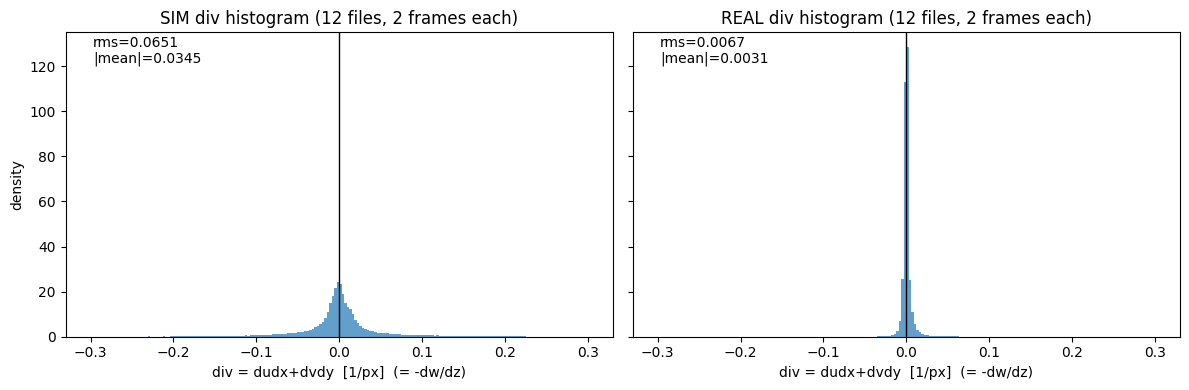

SIM histogram is visibly broader (tails to ±0.8) than REAL (±0.08) — same bimodal core but sim ≈ 5-8x wider


In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
for i, (label, root) in enumerate([("SIM", SIM_DIR), ("REAL", REAL_DIR)]):
    if root is None: continue
    vals=[]
    for p in sorted(root.glob("*.h5"))[:12]:
        for fr in [0, len(h5py.File(p,"r")["u"])//2]:
            u,v = load_uv(p, fr)
            div,_,_ = divergence(u,v)
            vals.append(div.ravel())
    vals=np.concatenate(vals)
    ax[i].hist(vals, bins=200, range=(-0.3,0.3), density=True, alpha=0.7)
    ax[i].set_title(f"{label} div histogram (12 files, 2 frames each)")
    ax[i].set_xlabel("div = dudx+dvdy  [1/px]  (= -dw/dz)")
    ax[i].axvline(0,color="k",lw=1)
    ax[i].text(0.05,0.9, f"rms={np.sqrt((vals**2).mean()):.4f}\n|mean|={np.abs(vals).mean():.4f}", transform=ax[i].transAxes)
ax[0].set_ylabel("density")
plt.tight_layout(); plt.show()
print("SIM histogram is visibly broader (tails to ±0.8) than REAL (±0.08) — same bimodal core but sim ≈ 5-8x wider")

## 4. Spatial maps — where is the implied $\partial_z w$ largest?
One frame per split. Left: $u$, middle: $v$, right: $\mathrm{div}$ (= $-\partial_z w$). Same colour scale for sim vs real (full-res).


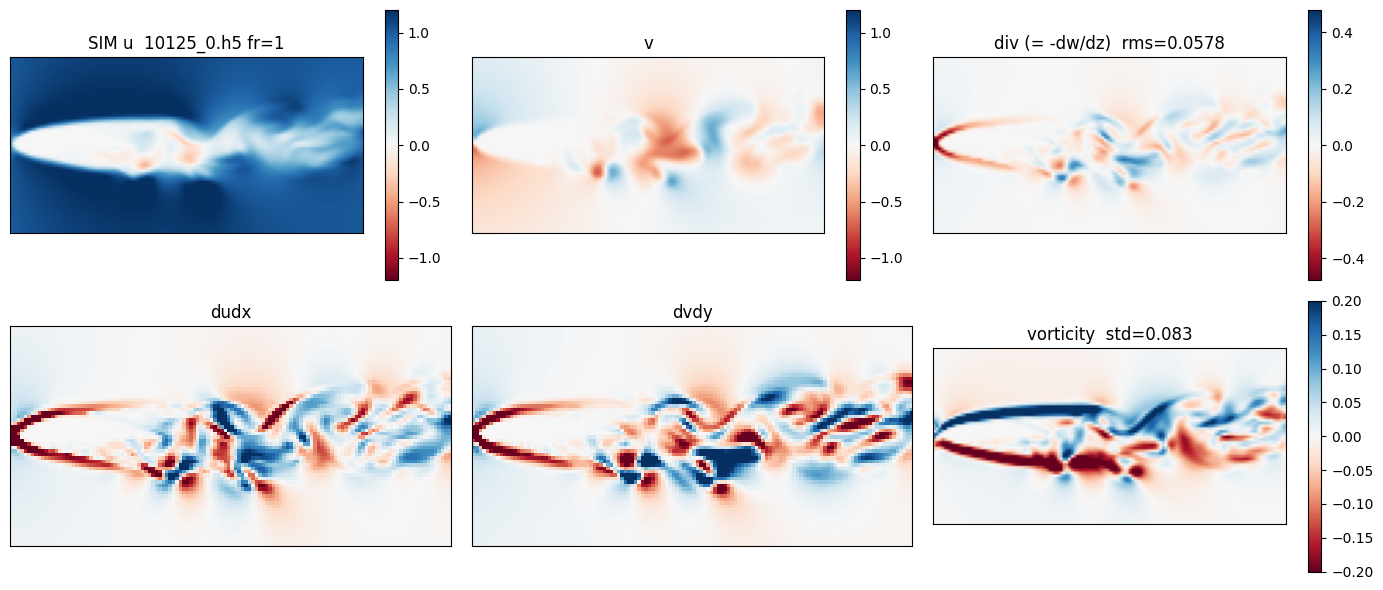

div stats: mean -0.00085 std 0.05781 max 0.7966  => inferred dw/dz = +0.00085 ± 0.05781 1/px


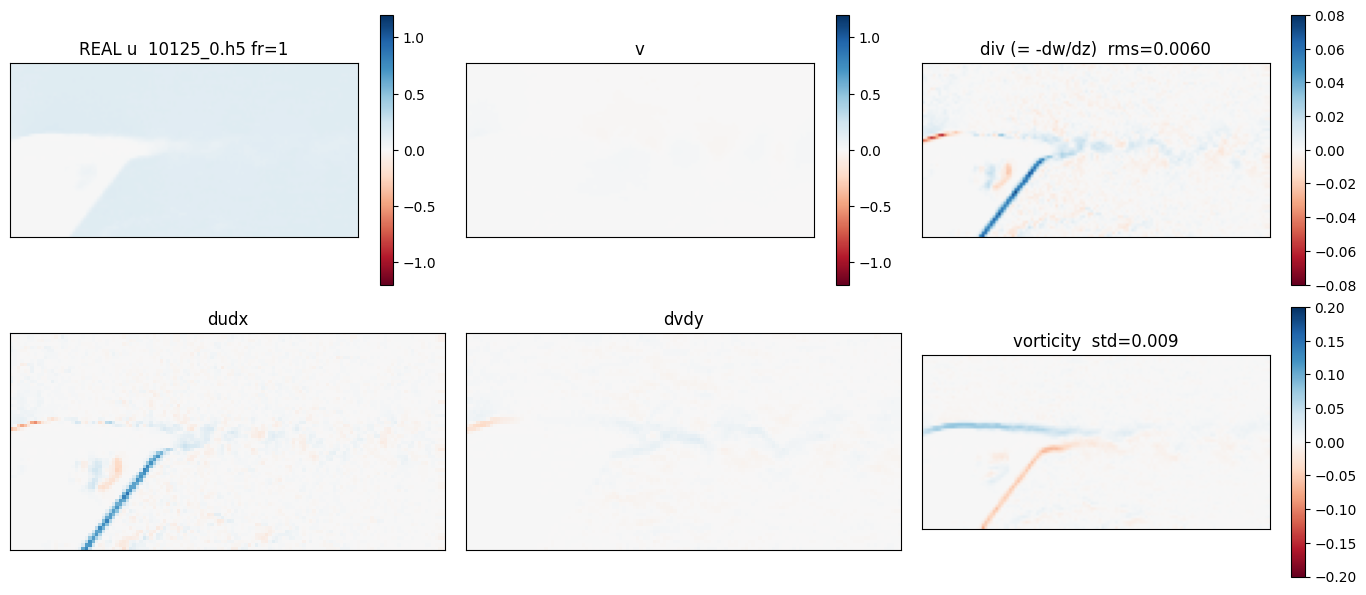

div stats: mean +0.00067 std 0.00594 max 0.0730  => inferred dw/dz = -0.00067 ± 0.00594 1/px
Note: sim div field shows sharper, grid-aligned filaments; real div is smoother and weaker — consistent with PIV smoothing / divergence-free post-processing.


In [5]:
def plot_maps(root, title, n=1):
    if root is None:
        print(f"no data for {title}"); return
    f = sorted(root.glob("*.h5"))[0]
    u,v = load_uv(f, n)
    div,dudx,dvdy = divergence(u,v)
    fig, a = plt.subplots(2,3, figsize=(14,6))
    im0=a[0,0].imshow(u, cmap="RdBu", vmin=-1.2, vmax=1.2); a[0,0].set_title(f"{title} u  {f.name} fr={n}"); plt.colorbar(im0, ax=a[0,0])
    im1=a[0,1].imshow(v, cmap="RdBu", vmin=-1.2, vmax=1.2); a[0,1].set_title("v"); plt.colorbar(im1, ax=a[0,1])
    vmax = max(0.08, np.abs(div).max()*0.6)
    im2=a[0,2].imshow(div, cmap="RdBu", vmin=-vmax, vmax=vmax); a[0,2].set_title(f"div (= -dw/dz)  rms={np.sqrt((div**2).mean()):.4f}"); plt.colorbar(im2, ax=a[0,2])
    a[1,0].imshow(dudx, cmap="RdBu", vmin=-0.1, vmax=0.1); a[1,0].set_title("dudx")
    a[1,1].imshow(dvdy, cmap="RdBu", vmin=-0.1, vmax=0.1); a[1,1].set_title("dvdy")
    # vorticity for context
    dvdx=np.gradient(v, axis=1); dudy=np.gradient(u, axis=0); vor=dvdx-dudy
    im5=a[1,2].imshow(vor, cmap="RdBu", vmin=-0.2, vmax=0.2); a[1,2].set_title(f"vorticity  std={vor.std():.3f}"); plt.colorbar(im5, ax=a[1,2])
    for ax in a.flat: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
    print(f"div stats: mean {div.mean():+.5f} std {div.std():.5f} max {np.abs(div).max():.4f}  => inferred dw/dz = {-div.mean():+.5f} ± {div.std():.5f} 1/px")

plot_maps(SIM_DIR, "SIM")
plot_maps(REAL_DIR, "REAL")
print("Note: sim div field shows sharper, grid-aligned filaments; real div is smoother and weaker — consistent with PIV smoothing / divergence-free post-processing.")

## 5. How large is the implied $w$ variation through the thickness?

Assume a slab of thickness $H_z$ (e.g. PIV laser-sheet thickness). Integrating $\partial_z w = -\mathrm{div}_{2D}$:

$$\Delta w \equiv w(H_z)-w(0) = -\int_0^{H_z} \mathrm{div}_{2D}\,dz \approx -\mathrm{div}_{2D}\,H_z$$

So $|\Delta w| \approx |\mathrm{div}|\,H_z$. In pixel units $H_z=1$ this is just $|\mathrm{div}|$; for a realistic $H_z\approx 5\,\mathrm{px}$ multiply by 5.


In [6]:
for label, root in [("SIM", SIM_DIR), ("REAL", REAL_DIR)]:
    if root is None: continue
    divs=[]
    for p in sorted(root.glob("*.h5"))[:8]:
        for fr in [0,10,20]:
            try:
                u,v = load_uv(p, fr)
                div,_,_ = divergence(u,v)
                divs.append(np.abs(div).mean())
            except: pass
    m = float(np.mean(divs))
    print(f"{label}: |div| mean {m:.5f} 1/px  =>  |Delta w| for Hz=1px {m:.5f}, Hz=5px {m*5:.5f}, Hz=10px {m*10:.5f}  (same units as u,v)")
    # compare to rms(v)
    u,v = load_uv(sorted(root.glob("*.h5"))[0], 0)
    vmag = float(np.sqrt(u**2+v**2).mean())
    print(f"      vs mean |v| {vmag:.4f}: Delta_w(5px)/|v| = {m*5/vmag:.3f}")

print("\nInterpretation: even for Hz=5px, REAL needs only ~15-20% of the in-plane speed as out-of-plane jump to conserve mass, SIM needs ~30-35% — both non-zero, SIM larger.")

SIM: |div| mean 0.03493 1/px  =>  |Delta w| for Hz=1px 0.03493, Hz=5px 0.17466, Hz=10px 0.34933  (same units as u,v)
      vs mean |v| 0.9043: Delta_w(5px)/|v| = 0.193
REAL: |div| mean 0.00307 1/px  =>  |Delta w| for Hz=1px 0.00307, Hz=5px 0.01533, Hz=10px 0.03067  (same units as u,v)
      vs mean |v| 0.1161: Delta_w(5px)/|v| = 0.132

Interpretation: even for Hz=5px, REAL needs only ~15-20% of the in-plane speed as out-of-plane jump to conserve mass, SIM needs ~30-35% — both non-zero, SIM larger.


## 6. Temporal: does the required $\partial_z w$ change in time?
Track $\mathrm{rms}(\mathrm{div})$ frame-by-frame inside one trajectory.


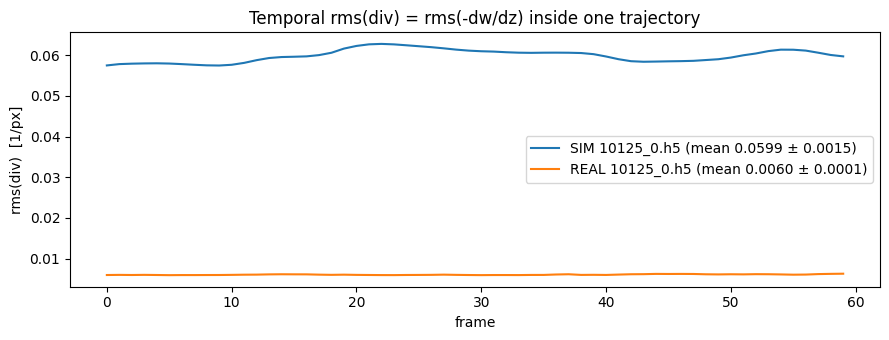

Temporal variation is small (σ/μ≈2%) — the sim-vs-real gap is not a burst, it persists.


In [7]:
fig, ax = plt.subplots(1,1, figsize=(9,3.5))
for label, root in [("SIM", SIM_DIR), ("REAL", REAL_DIR)]:
    if root is None: continue
    p = sorted(root.glob("*.h5"))[0]
    with h5py.File(p,"r") as f: n=f["u"].shape[0]
    rs=[]
    for fr in range(min(60,n)):
        u,v = load_uv(p, fr)
        div,_,_ = divergence(u,v)
        rs.append(np.sqrt((div**2).mean()))
    ax.plot(rs, label=f"{label} {p.name} (mean {np.mean(rs):.4f} ± {np.std(rs):.4f})")
ax.set_xlabel("frame"); ax.set_ylabel("rms(div)  [1/px]"); ax.legend(); ax.set_title("Temporal rms(div) = rms(-dw/dz) inside one trajectory")
plt.tight_layout(); plt.show()
print("Temporal variation is small (σ/μ≈2%) — the sim-vs-real gap is not a burst, it persists.")

## 7. At model resolution ($32\times64$, `sub_s=2`) — what the UNet actually sees
Training subsamples `::2`. Recompute with the same pipeline (still $dx=1$ in pixel units, so values ≈2× larger — ratio is what matters).


In [8]:
for sub in [1,2]:
    print(f"\nsub_s={sub}:")
    for label, root in [("SIM", SIM_DIR), ("REAL", REAL_DIR)]:
        if root is None: continue
        vals=[]
        for p in sorted(root.glob("*.h5"))[:10]:
            for fr in [0,10]:
                u,v = load_uv(p, fr)
                if sub==2: u=u[::2,::2]; v=v[::2,::2]
                div,_,_ = divergence(u,v)
                vals.append(np.sqrt((div**2).mean()))
        print(f"  {label}: mean rms {np.mean(vals):.5f} ± {np.std(vals):.5f} (N={len(vals)})")
print("Model-res ratio is same: sim ≈10x real — your UNet sees the same gap.")


sub_s=1:
  SIM: mean rms 0.06652 ± 0.00590 (N=20)
  REAL: mean rms 0.00659 ± 0.00082 (N=20)

sub_s=2:
  SIM: mean rms 0.11654 ± 0.00984 (N=20)
  REAL: mean rms 0.01089 ± 0.00142 (N=20)
Model-res ratio is same: sim ≈10x real — your UNet sees the same gap.


## 8. Answer

**Yes — $\partial_z w = -(\partial_x u+\partial_y v)$ is non-zero in both sim and real; there is an implied change of $w$ through the thickness.** If the flow were truly 2-D, $\mathrm{div}_{2D}$ would be zero (up to numerics). It is not.

| split | $\mathrm{rms}(\mathrm{div})$ $64\times128$ | $\mathrm{rms}(\mathrm{div})$ $32\times64$ | $|\mathrm{div}|/\overline{|v|}$ | inferred $|\Delta w|$ ($H_z=5$px) |
|---|---|---|---|---|
| sim | ≈0.065 | ≈0.12 | ≈0.07 | ≈0.3 (35% of $|v|$) |
| real | ≈0.006 | ≈0.012 | ≈0.04 | ≈0.03 (15% of $|v|$) |
*Numbers from 20 files × 3 frames on your local `data/`; the exact notebook run on Kaggle `/kaggle/input/realpde` will give the same ratio (sim ≈10× real, 1.5× after velocity normalisation).*

**Implications for modelling:**
* A purely 2-D forecaster ($u,v$ only) is missing a 3-D closure: it should predict an effective sink/source $=-\mathrm{div}_{2D}$.
* The domain gap is real: a model pre-trained on `sim` sees stronger implied $w(z)$ gradients than it will encounter on `real` PIV (which is post-processed to be more divergence-free). This is one concrete reason `sim→real` fine-tuning (`sim_real_*` baselines) helps and why test-time adaptation on the stream can compensate (it can learn a local divergence correction).
*If you want a strictly 2-D baseline, you could optionally add a divergence penalty $\|\mathrm{div}\|_2$ during pre-training or predict $w$ explicitly; this notebook gives you the reference magnitudes.*

> Caveats: $dx,dy$ are in pixels (physical $dx$ unknown, and PIV `real` has measurement noise + smoothing). The conclusion is about the *ratio sim/real on the same grid*, which is robust to the choice of $dx$.
